# Methodology Chapter Figures

This notebook builds the five figures referenced in the methodology chapter draft
(`documentation/august_draft/4_Chapter_methodology/g_methodology_2026-08-15_clean_all_applied.tex`):

1. `fig:pipeline-overview` -- overall pipeline flowchart (schematic)
2. `fig:splits-combined` -- 3-panel figure: plot-level leakage, spatial-block split with buffer, temporal split
3. `fig:age-linearity` -- training-partition age distribution with fitted Chapman-Richards curve
4. `fig:model-architecture` -- shared DNN/PINN architecture block diagram (schematic)
5. `fig:rq3-attribution` -- RQ3 target construction and attribution models, including the GNNWR mechanism (schematic)

Like `notebooks/spatial_analysis/spatial_temporal_split_visualisation.ipynb`, this notebook does not
reimplement any modelling logic -- data-driven panels (2 and 3) import the real split functions
(`models/common/splits.py`) and the real Chapman-Richards fit (`models/chapman_richards/chapman_richards.py`)
used by the model scripts, so what is plotted is exactly what those scripts do. The two purely
schematic figures (1 and 4) and the mechanism part of figure 5 have no underlying dataset to plot --
they are box-and-arrow diagrams built directly from the figure captions already written in the
chapter, so their content matches the (already-approved) caption text exactly.

Every figure is saved as a PNG into `documentation/august_draft/4_Chapter_methodology/figures/`,
ready to be included in the chapter with `\includegraphics`.

**Colour choice**: all figures use a small, fixed, colourblind-safe categorical palette (never more
than 4-5 colours, assigned to the same meaning in every figure) rather than a default matplotlib
cycle, following this project's `dataviz` skill guidance (categorical hues assigned by identity, in a
fixed order, never cycled or reused for a different meaning).

In [1]:
# Purpose: Make the models/ package importable from this notebook, the same way
# notebooks/spatial_analysis/spatial_temporal_split_visualisation.ipynb does it.
# Key logic: walk upward from this notebook's folder until a folder containing
# both README.md and data/ is found -- that folder is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# All figures are saved here, as PNGs ready for \includegraphics in the chapter.
FIGURES_DIR = project_root / "documentation" / "august_draft" / "4_Chapter_methodology" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("project_root:", project_root)
print("figures will be saved to:", FIGURES_DIR)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss
figures will be saved to: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/documentation/august_draft/4_Chapter_methodology/figures


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle

# Figures are for a printed PDF (no hover/interactivity), so this notebook keeps to the
# print-relevant parts of the dataviz skill: a fixed, colourblind-safe categorical palette,
# thin marks, one axis per panel (no dual-axis charts), and selective direct labels instead
# of a legend wherever a direct label fits.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# A small, fixed categorical palette (Okabe-Ito, a standard colourblind-safe set), with each
# colour assigned to ONE fixed meaning below and reused with that same meaning in every figure
# in this notebook -- never cycled, never repurposed for a different category.
COLOR_TRAIN = "#0072B2"      # blue
COLOR_VAL = "#E69F00"        # orange
COLOR_TEST = "#009E73"       # green
COLOR_BUFFER = "#999999"     # neutral grey -- excluded/removed rows
COLOR_CURVE = "#D55E00"      # vermillion -- fitted model / analytical curve
COLOR_NEUTRAL_BOX = "#F0F0F0"  # schematic-diagram box fill
COLOR_NEUTRAL_EDGE = "#555555"  # schematic-diagram box edge

print("Setup complete.")

Setup complete.


## Figure: `fig:age-linearity`

**Chapter spec (from the LaTeX comment above the placeholder):** training-partition age
distribution as a histogram (4survey cohort), with the observed age range shown against a single
fitted Chapman-Richards curve (Equation `eq:cr`) over the same age range, to show visually that the
observed section of the curve sits on its near-linear early-to-mid segment -- the reason a plain
linear regression baseline is defensible despite the true age-height relationship being nonlinear.

**Data/model used:** the real training partition is reconstructed exactly as
`models/baselines/run_baselines.py` builds it (`filter_data(maturity_age_min=30)` then the primary
`spatial_block_split`, train rows only), and the overlaid curve is the *already-fitted* curve saved to
`outputs/chapman_richards/4survey/params.json` (not refit here), so the curve shown is exactly the one
actually used as the PINN's physics anchor.

In [3]:
from models.chapman_richards.chapman_richards import chapman_richards
from models.common.data import filter_data, load_cohort_data
from models.common.geo import load_plot_coordinates
from models.common.splits import spatial_block_split

COHORT = "4survey"  # primary cohort throughout the chapter
AGE_COL = "Age"
HEIGHT_COL = "elev_percentile_95th"
SPATIAL_BUFFER_METRES = 60
SPLIT_SEED = 42

# Step 1: load the same columns run_baselines.py loads, apply the same maturity filter.
raw_table = load_cohort_data(COHORT)
filtered_table = filter_data(raw_table, maturity_age_min=30)

# Step 2: apply the exact same primary spatial-block split (whole compartments, 60m buffer,
# seed 42) that produces the training partition the real Chapman-Richards curve was fit on.
coordinates_df = load_plot_coordinates()
filtered_table = filtered_table.copy()
filtered_table["split"] = spatial_block_split(
    filtered_table, block_col="cpmt", buffer_distance=SPATIAL_BUFFER_METRES,
    coordinates_df=coordinates_df, seed=SPLIT_SEED,
)
train_df = filtered_table[filtered_table["split"] == "train"]

print(f"{COHORT}: {len(train_df):,} training rows after maturity filter + spatial-block split")
print(f"Training age range: {train_df[AGE_COL].min():.0f} to {train_df[AGE_COL].max():.0f} years")

# Step 3: load the already-fitted Chapman-Richards curve for this cohort (not refit here).
with open(project_root / "outputs" / "chapman_richards" / COHORT / "params.json") as f:
    cr_params = json.load(f)
print("Loaded fitted CR params:", cr_params)

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Buffer: 2,186 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
4survey: 129,672 training rows after maturity filter + spatial-block split
Training age range: 15 to 94 years
Loaded fitted CR params: {'y_max': 51.96307116000001, 'k': 0.010287895198776128, 'p': 0.8648990817686512, 'cohort': '4survey', 'n_rows_fit': 139472, 'fit_date': '2026-08-09T22:51:44.508825+00:00'}


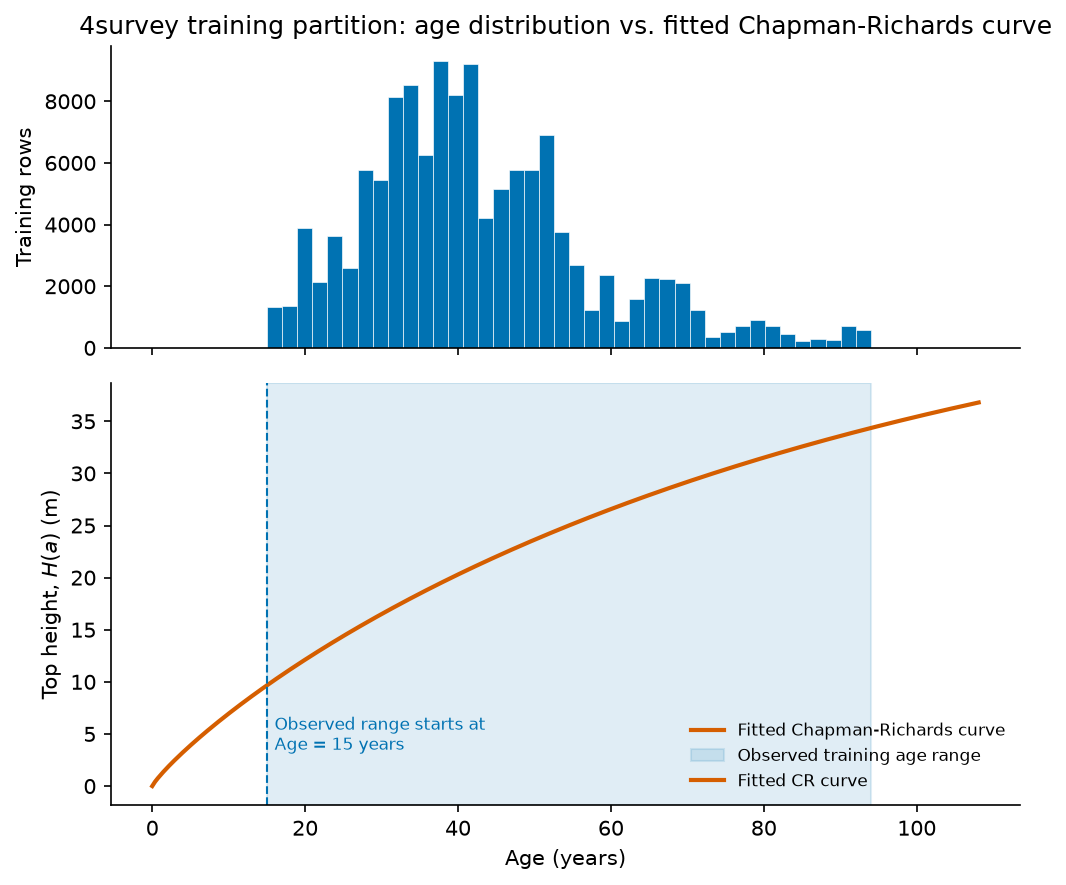

Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/documentation/august_draft/4_Chapter_methodology/figures/age_linearity.png


In [4]:
# Two panels stacked on a shared x-axis (age), rather than one panel with two y-axes
# (counts vs. metres) -- a dual-axis chart with two different y-scales is misleading (see the
# dataviz skill's anti-patterns), so a shared x-axis with two honestly-scaled panels is used
# instead.
fig, (ax_hist, ax_curve) = plt.subplots(
    2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1.4]},
)

# --- Top panel: age histogram of the training partition ---
ax_hist.hist(train_df[AGE_COL], bins=40, color=COLOR_TRAIN, edgecolor="white", linewidth=0.3)
ax_hist.set_ylabel("Training rows")
ax_hist.set_title(f"{COHORT} training partition: age distribution vs. fitted Chapman-Richards curve")

# --- Bottom panel: fitted CR curve over the same age range, observed range highlighted ---
age_min_observed = train_df[AGE_COL].min()
age_max_observed = train_df[AGE_COL].max()

# Curve is drawn from age 0 so the reader can see the full sigmoid shape, not just the
# observed slice -- the observed range is then highlighted on top of it.
age_full_range = np.linspace(0, age_max_observed * 1.15, 300)
height_full_range = chapman_richards(age_full_range, cr_params["y_max"], cr_params["k"], cr_params["p"])
ax_curve.plot(age_full_range, height_full_range, color=COLOR_CURVE, linewidth=2, label="Fitted Chapman-Richards curve")

# Shade the observed training-age window directly on the curve panel.
ax_curve.axvspan(age_min_observed, age_max_observed, color=COLOR_TRAIN, alpha=0.12, label="Observed training age range")
ax_curve.axvline(age_min_observed, color=COLOR_TRAIN, linewidth=1, linestyle="--")

# Direct label instead of a legend box, placed near the shaded band itself.
ax_curve.text(
    age_min_observed + 1, height_full_range.max() * 0.08,
    f"Observed range starts at\nAge = {age_min_observed:.0f} years",
    color=COLOR_TRAIN, fontsize=8, va="bottom",
)
ax_curve.plot([], [], color=COLOR_CURVE, linewidth=2, label="Fitted CR curve")  # legend proxy

ax_curve.set_xlabel("Age (years)")
ax_curve.set_ylabel("Top height, $H(a)$ (m)")
ax_curve.legend(loc="lower right", frameon=False, fontsize=8)

plt.tight_layout()
out_path = FIGURES_DIR / "age_linearity.png"
plt.savefig(out_path)
plt.show()
print("Saved ->", out_path)

## Figure: `fig:splits-combined`

**Chapter spec:** a combined 3-panel figure.
- **Panel A** -- plot-level split: nearest-neighbour leakage, with a distance callout.
- **Panel B** -- spatial-block split: whole compartments held out, with the 60m buffer ring shown.
- **Panel C** -- temporal split: timeline with the 2012-2021 survey gap marked.

This reuses the exact split functions from `models/common/splits.py`, following the same pattern as
`notebooks/spatial_analysis/spatial_temporal_split_visualisation.ipynb` (which already has working
code for panels A and B individually -- this section adapts that code into one combined figure with
a temporal panel added, rather than three separate figures).

**Note on the "reuse the Data chapter's `fig:data-cohort-map` base layer" instruction in the chapter
comment:** that Data-chapter figure does not exist yet either (its own `.tex` file still shows a plain
`MAP PLACEHOLDER`, with no notebook or script producing it found in this repository). So the map
styling below is written as a small reusable function (`plot_split_map`, next cell) that the Data
chapter's own figure can call later for visual consistency, rather than pointing at a base layer that
does not exist yet.

In [5]:
from models.common.geo import find_train_plots_near_holdout
from models.common.splits import plot_level_split, temporal_split

COHORT_FOR_SPLITS = "4survey"

# Reload the raw (row-per-survey) master table for this cohort, joined to plot coordinates --
# splits are usually shown at plot level (one point per plot), matching the existing
# spatial_temporal_split_visualisation.ipynb convention.
master_path = project_root / "data" / "processed" / "master" / f"clean_master_{COHORT_FOR_SPLITS}.parquet"
master_df = pd.read_parquet(master_path)
# coordinates_df already has its own "cpmt" column (matching master's), so only x/y are
# taken from it here -- merging the whole thing would otherwise collide into cpmt_x/cpmt_y.
master_df = master_df.merge(coordinates_df[["identification", "x", "y"]], on="identification", how="left")
plots_df = master_df.drop_duplicates("identification").copy()

print(f"{COHORT_FOR_SPLITS}: {len(plots_df):,} unique plots with coordinates")

4survey: 71,766 unique plots with coordinates


Panel A callout: closest held-out/train pair is 8.2 m apart


  Buffer: 3,297 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


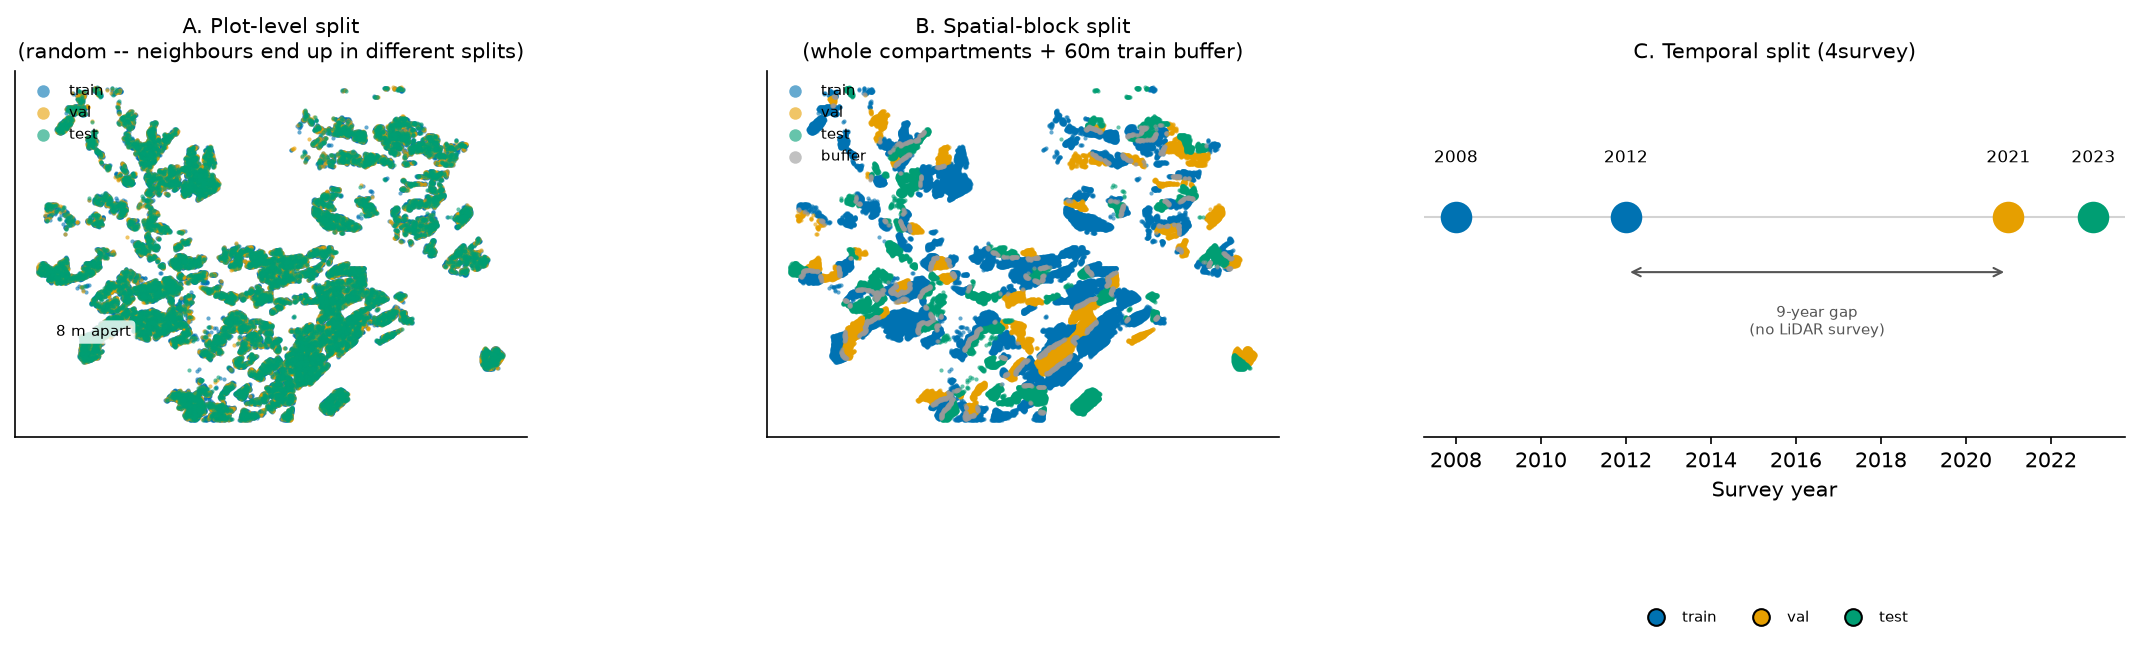

Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/documentation/august_draft/4_Chapter_methodology/figures/splits_combined.png


In [6]:
def plot_split_map(df, split_col, title, ax, show_legend=True):
    # One consistent colour per split label -- reused everywhere in this notebook, and
    # written as its own function so a later Data-chapter figure can reuse the same styling
    # (see the markdown note above).
    split_colors = {"train": COLOR_TRAIN, "val": COLOR_VAL, "test": COLOR_TEST, "buffer": COLOR_BUFFER}
    for split_name, color in split_colors.items():
        subset = df[df[split_col] == split_name]
        if len(subset) == 0:
            continue
        ax.scatter(subset["x"], subset["y"], c=color, s=4, alpha=0.6, label=split_name, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    if show_legend:
        ax.legend(markerscale=3, loc="upper left", fontsize=7, frameon=False)


fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel A: plot-level split (random shuffle -- leaks spatially) ---
plots_df["plot_split"] = plot_level_split(plots_df, seed=42)
plot_split_map(plots_df, "plot_split", "A. Plot-level split\n(random -- neighbours end up in different splits)", ax_a)

# Distance callout: pick one held-out (val/test) plot and find its nearest TRAIN neighbour under
# this split, to show concretely how close a "leaking" pair of plots can be.
from scipy.spatial import cKDTree

held_out_plots = plots_df[plots_df["plot_split"].isin(["val", "test"])]
train_plots_a = plots_df[plots_df["plot_split"] == "train"]
train_tree = cKDTree(train_plots_a[["x", "y"]].values)
distances, nearest_idx = train_tree.query(held_out_plots[["x", "y"]].values, k=1)
closest_pair_row = distances.argmin()
closest_distance = distances[closest_pair_row]
held_out_point = held_out_plots.iloc[closest_pair_row]
train_point = train_plots_a.iloc[nearest_idx[closest_pair_row]]

ax_a.annotate(
    "", xy=(train_point["x"], train_point["y"]), xytext=(held_out_point["x"], held_out_point["y"]),
    arrowprops=dict(arrowstyle="-", color="black", linewidth=1),
)
mid_x = (train_point["x"] + held_out_point["x"]) / 2
mid_y = (train_point["y"] + held_out_point["y"]) / 2
ax_a.text(mid_x, mid_y, f"{closest_distance:.0f} m apart", fontsize=7, ha="center",
          bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=0.8))

print(f"Panel A callout: closest held-out/train pair is {closest_distance:.1f} m apart")

# --- Panel B: spatial-block split with buffer ---
plots_df["buffered_split"] = spatial_block_split(
    plots_df, block_col="cpmt", buffer_distance=SPATIAL_BUFFER_METRES,
    coordinates_df=coordinates_df, seed=42,
)
plot_split_map(plots_df, "buffered_split", f"B. Spatial-block split\n(whole compartments + {SPATIAL_BUFFER_METRES}m train buffer)", ax_b, show_legend=False)
ax_b.legend(markerscale=3, loc="upper left", fontsize=7, frameon=False)

# --- Panel C: temporal split, shown as a timeline of survey years ---
TEMPORAL_YEARS = {"train_years": [2008, 2012], "val_years": [2021], "test_years": [2023]}
master_df["temporal_split"] = temporal_split(master_df, year_col="LiDAR_year", **TEMPORAL_YEARS)

split_colors = {"train": COLOR_TRAIN, "val": COLOR_VAL, "test": COLOR_TEST}
all_years = sorted(master_df["LiDAR_year"].unique())
for year in all_years:
    year_split = master_df.loc[master_df["LiDAR_year"] == year, "temporal_split"].iloc[0]
    ax_c.scatter(year, 0, s=200, color=split_colors[year_split], zorder=3)
    ax_c.text(year, 0.15, str(year), ha="center", fontsize=8)

ax_c.axhline(0, color="lightgrey", zorder=1, linewidth=1)
# Mark the real gap between the last training survey year and the validation year.
last_train_year = max(TEMPORAL_YEARS["train_years"])
val_year = TEMPORAL_YEARS["val_years"][0]
ax_c.annotate(
    "", xy=(val_year, -0.15), xytext=(last_train_year, -0.15),
    arrowprops=dict(arrowstyle="<->", color=COLOR_NEUTRAL_EDGE, linewidth=1),
)
ax_c.text(
    (last_train_year + val_year) / 2, -0.32, f"{val_year - last_train_year}-year gap\n(no LiDAR survey)",
    ha="center", fontsize=7, color=COLOR_NEUTRAL_EDGE,
)

ax_c.set_ylim(-0.6, 0.4)
ax_c.set_yticks([])
ax_c.set_xlabel("Survey year")
ax_c.set_title(f"C. Temporal split ({COHORT_FOR_SPLITS})", fontsize=10)
for spine in ["left", "right", "top"]:
    ax_c.spines[spine].set_visible(False)
# Direct labels instead of a legend, since there are only 3 points.
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markersize=8, label=name)
    for name, color in split_colors.items()
]
ax_c.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=7, frameon=False, bbox_to_anchor=(0.5, -0.55))

plt.tight_layout()
out_path = FIGURES_DIR / "splits_combined.png"
plt.savefig(out_path)
plt.show()
print("Saved ->", out_path)

## Shared helper for the schematic figures

Figures `fig:pipeline-overview`, `fig:model-architecture`, and the mechanism part of
`fig:rq3-attribution` have no underlying dataset -- they are diagrams of the pipeline/architecture
itself. The chapter already has final caption text for each (written earlier in this project), so the
diagrams below are built to match that caption text exactly, using a small helper for drawing
consistent boxes and arrows rather than one-off styling per figure.

In [7]:
def draw_box(ax, x, y, width, height, label, facecolor=COLOR_NEUTRAL_BOX, edgecolor=COLOR_NEUTRAL_EDGE, fontsize=9):
    # Draws one rounded box with centred text -- used for every step in every schematic
    # diagram below, so all boxes in this notebook look the same.
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        facecolor=facecolor, edgecolor=edgecolor, linewidth=1.2,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=fontsize, wrap=True)
    return box


def draw_arrow(ax, start_xy, end_xy, style="-|>", color=COLOR_NEUTRAL_EDGE, linestyle="solid"):
    # Draws one arrow between two box edges -- used for every connection below.
    arrow = FancyArrowPatch(
        start_xy, end_xy, arrowstyle=style, mutation_scale=12,
        color=color, linewidth=1.2, linestyle=linestyle,
    )
    ax.add_patch(arrow)
    return arrow


def new_schematic_axes(figsize, xlim, ylim):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    return fig, ax

print("Schematic helpers ready.")

Schematic helpers ready.


## Figure: `fig:pipeline-overview`

**Chapter spec:** an end-to-end flowchart. Raw LiDAR/survey data -> cleaning and cohort construction
(4survey/6survey) -> the four data-splitting strategies (Table `tab:splits-summary`) -> the shared
Set1-4 feature-screening process -> the RQ1/RQ2/RQ3 model families -> the evaluation/interpretation
stage (predictive diagnostics, spatial autocorrelation, feature attribution), ending in a per-plot
coefficient table (GNNWR) and a residual spatial-autocorrelation diagnostic. No branch currently
produces a rendered coefficient or residual map.

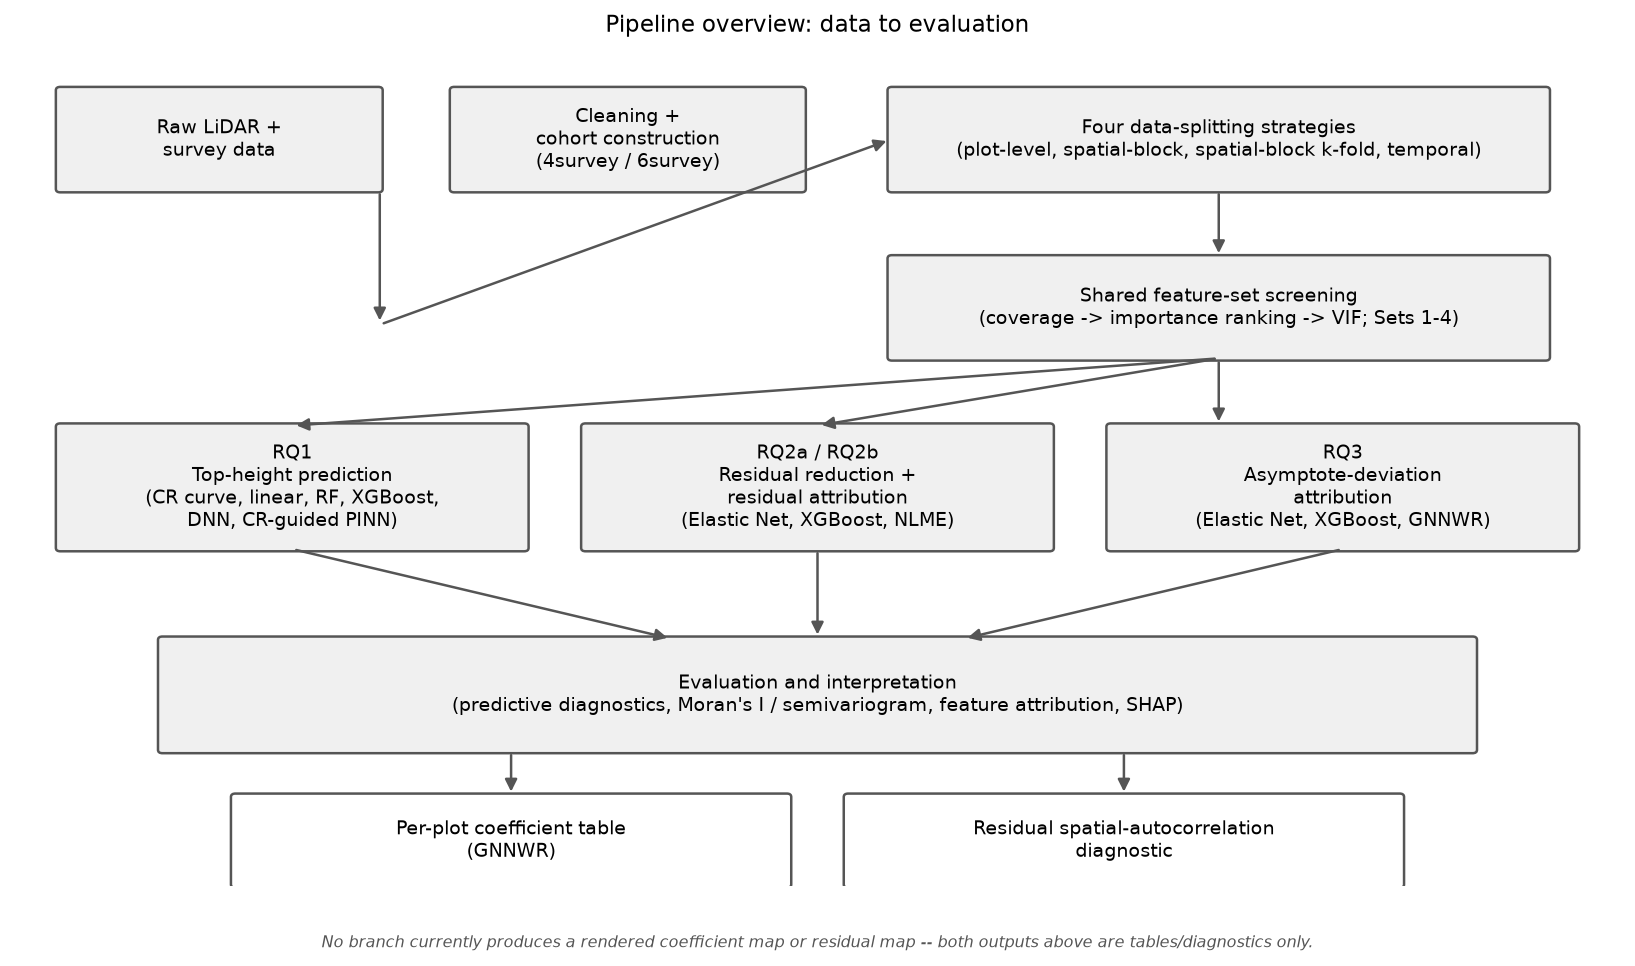

Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/documentation/august_draft/4_Chapter_methodology/figures/pipeline_overview.png


In [8]:
fig, ax = new_schematic_axes(figsize=(11, 6.5), xlim=(0, 11), ylim=(0, 7.5))

# Stage 1: data
draw_box(ax, 0.3, 6.2, 2.2, 0.9, "Raw LiDAR +\nsurvey data")
draw_box(ax, 3.0, 6.2, 2.4, 0.9, "Cleaning +\ncohort construction\n(4survey / 6survey)")

# Stage 2: splits
draw_box(ax, 6.0, 6.2, 4.5, 0.9, "Four data-splitting strategies\n(plot-level, spatial-block, spatial-block k-fold, temporal)")

# Stage 3: feature screening
draw_box(ax, 6.0, 4.7, 4.5, 0.9, "Shared feature-set screening\n(coverage -> importance ranking -> VIF; Sets 1-4)")

# Stage 4: RQ1/2/3 model families
draw_box(ax, 0.3, 3.0, 3.2, 1.1, "RQ1\nTop-height prediction\n(CR curve, linear, RF, XGBoost,\nDNN, CR-guided PINN)")
draw_box(ax, 3.9, 3.0, 3.2, 1.1, "RQ2a / RQ2b\nResidual reduction +\nresidual attribution\n(Elastic Net, XGBoost, NLME)")
draw_box(ax, 7.5, 3.0, 3.2, 1.1, "RQ3\nAsymptote-deviation\nattribution\n(Elastic Net, XGBoost, GNNWR)")

# Stage 5: evaluation / interpretation
draw_box(ax, 1.0, 1.2, 9.0, 1.0, "Evaluation and interpretation\n(predictive diagnostics, Moran's I / semivariogram, feature attribution, SHAP)")

# Stage 6: outputs
draw_box(ax, 1.5, 0.0, 3.8, 0.8, "Per-plot coefficient table\n(GNNWR)", facecolor="#FFFFFF")
draw_box(ax, 5.7, 0.0, 3.8, 0.8, "Residual spatial-autocorrelation\ndiagnostic", facecolor="#FFFFFF")

# Arrows: main vertical flow
draw_arrow(ax, (2.5, 6.2), (2.5, 5.0))
draw_arrow(ax, (2.5, 5.0), (6.0, 6.65))
draw_arrow(ax, (8.25, 6.2), (8.25, 5.6))
draw_arrow(ax, (8.25, 4.7), (8.25, 4.1))
draw_arrow(ax, (8.25, 4.7), (1.9, 4.1))
draw_arrow(ax, (8.25, 4.7), (5.5, 4.1))
draw_arrow(ax, (1.9, 3.0), (4.5, 2.2))
draw_arrow(ax, (5.5, 3.0), (5.5, 2.2))
draw_arrow(ax, (9.1, 3.0), (6.5, 2.2))
draw_arrow(ax, (3.4, 1.2), (3.4, 0.8))
draw_arrow(ax, (7.6, 1.2), (7.6, 0.8))

# Note on the unfinished branch, drawn as plain text rather than an arrow to nothing.
ax.text(
    5.5, -0.55,
    "No branch currently produces a rendered coefficient map or residual map -- both outputs above are tables/diagnostics only.",
    ha="center", fontsize=7.5, style="italic", color=COLOR_NEUTRAL_EDGE,
)

ax.set_title("Pipeline overview: data to evaluation", fontsize=11)
plt.tight_layout()
out_path = FIGURES_DIR / "pipeline_overview.png"
plt.savefig(out_path)
plt.show()
print("Saved ->", out_path)

## Figure: `fig:model-architecture`

**Chapter spec:** a block diagram. Age + non-environmental features feed the shared 3x128 trunk to
predict height. Terrain/wind features feed small (16-unit) sub-networks producing an additive
$y_{\max}$ adjustment and, for the rate-conditioned variant, a multiplicative log-space $k$
adjustment. Predicted height and age feed an autograd box (`dH/da`) compared against the analytical
CR derivative to give the physics loss. A second small diagram shows two real, pre-built
consecutive-survey observations of one plot, differenced and compared to the CR derivative at
mid-age, to give the trajectory loss.

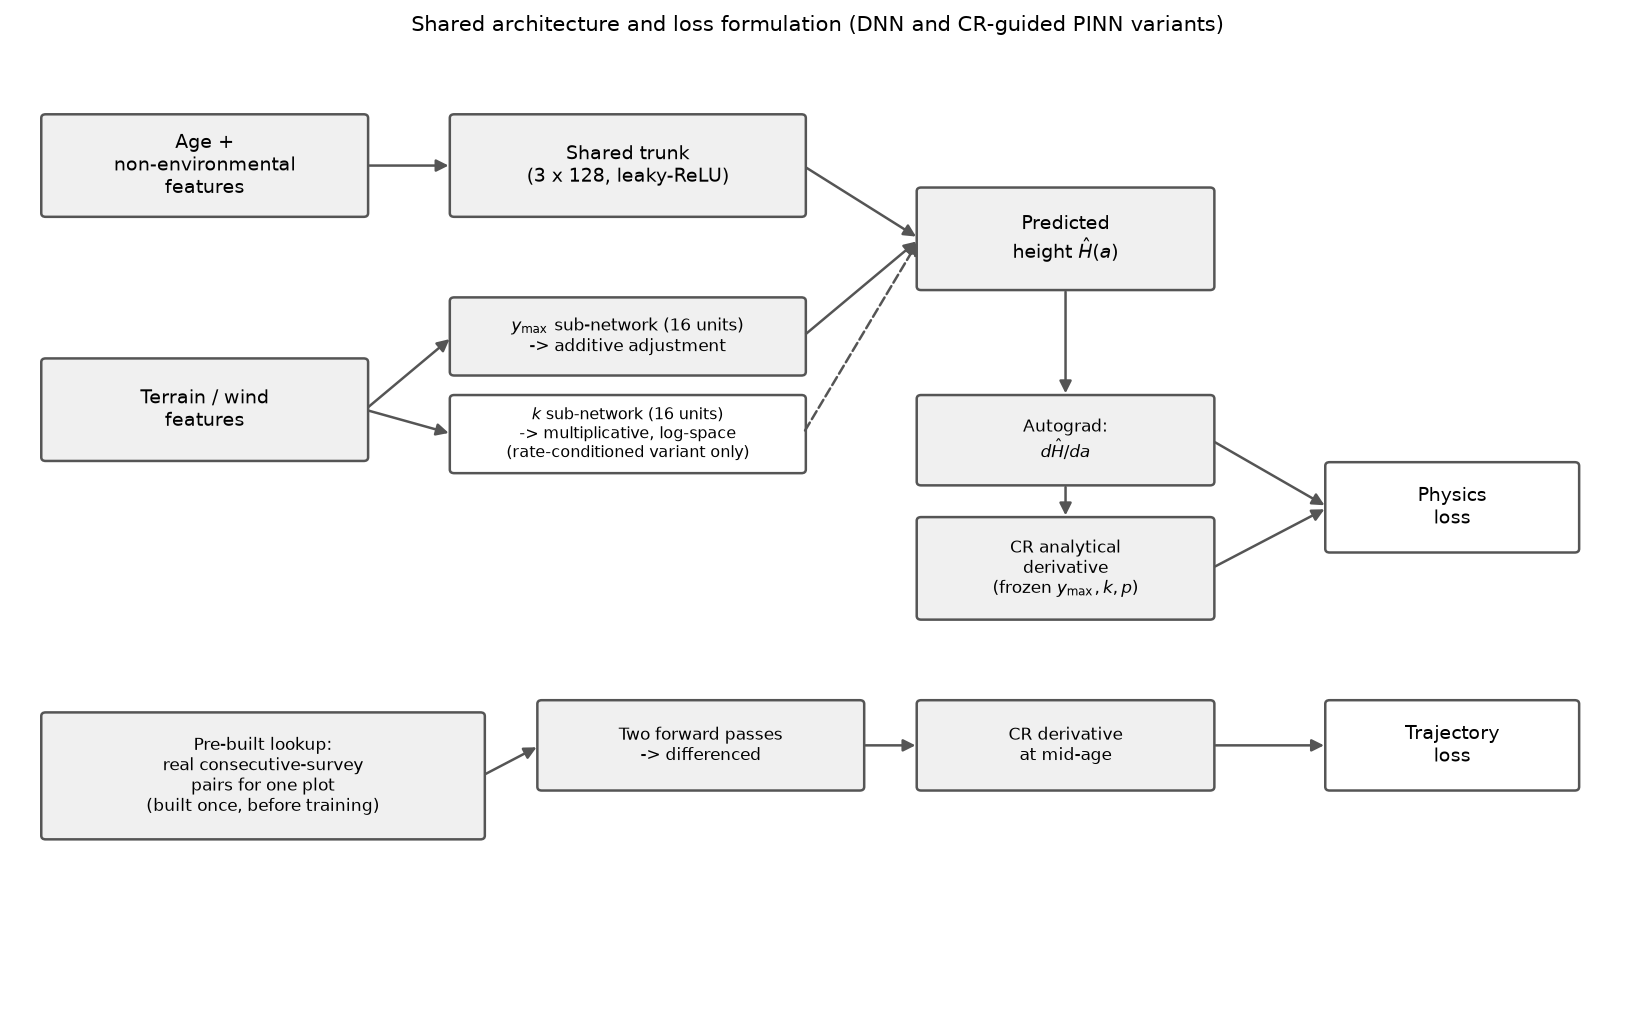

Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/documentation/august_draft/4_Chapter_methodology/figures/model_architecture.png


In [9]:
fig, ax = new_schematic_axes(figsize=(11, 7), xlim=(0, 11), ylim=(0, 8))

# --- Inputs ---
draw_box(ax, 0.2, 6.6, 2.2, 0.8, "Age +\nnon-environmental\nfeatures")
draw_box(ax, 0.2, 4.6, 2.2, 0.8, "Terrain / wind\nfeatures")

# --- Trunk ---
draw_box(ax, 3.0, 6.6, 2.4, 0.8, "Shared trunk\n(3 x 128, leaky-ReLU)")

# --- Sub-networks ---
draw_box(ax, 3.0, 5.3, 2.4, 0.6, "$y_{\\max}$ sub-network (16 units)\n-> additive adjustment", fontsize=8)
draw_box(ax, 3.0, 4.5, 2.4, 0.6, "$k$ sub-network (16 units)\n-> multiplicative, log-space\n(rate-conditioned variant only)", facecolor="#FFFFFF", fontsize=7.5)

# --- Predicted height ---
draw_box(ax, 6.2, 6.0, 2.0, 0.8, "Predicted\nheight $\\hat H(a)$")

# --- Physics loss branch ---
draw_box(ax, 6.2, 4.4, 2.0, 0.7, "Autograd:\n$d\\hat H / da$", fontsize=8)
draw_box(ax, 6.2, 3.3, 2.0, 0.8, "CR analytical\nderivative\n(frozen $y_{\\max}, k, p$)", fontsize=8)
draw_box(ax, 9.0, 3.85, 1.7, 0.7, "Physics\nloss", facecolor="#FFFFFF")

# --- Trajectory loss branch (small fixed lookup, not synthesised per batch) ---
draw_box(ax, 0.2, 1.5, 3.0, 1.0, "Pre-built lookup:\nreal consecutive-survey\npairs for one plot\n(built once, before training)", fontsize=8)
draw_box(ax, 3.6, 1.9, 2.2, 0.7, "Two forward passes\n-> differenced", fontsize=8)
draw_box(ax, 6.2, 1.9, 2.0, 0.7, "CR derivative\nat mid-age", fontsize=8)
draw_box(ax, 9.0, 1.9, 1.7, 0.7, "Trajectory\nloss", facecolor="#FFFFFF")

# --- Arrows ---
draw_arrow(ax, (2.4, 7.0), (3.0, 7.0))
draw_arrow(ax, (2.4, 5.0), (3.0, 5.6))
draw_arrow(ax, (2.4, 5.0), (3.0, 4.8))
draw_arrow(ax, (5.4, 7.0), (6.2, 6.4))
draw_arrow(ax, (5.4, 5.6), (6.2, 6.4))
draw_arrow(ax, (5.4, 4.8), (6.2, 6.4), linestyle="dashed")
draw_arrow(ax, (7.2, 6.0), (7.2, 5.1))
draw_arrow(ax, (7.2, 4.4), (7.2, 4.1))
draw_arrow(ax, (8.2, 4.75), (9.0, 4.2))
draw_arrow(ax, (8.2, 3.7), (9.0, 4.2))

draw_arrow(ax, (3.2, 2.0), (3.6, 2.25))
draw_arrow(ax, (5.8, 2.25), (6.2, 2.25))
draw_arrow(ax, (8.2, 2.25), (9.0, 2.25))

ax.set_title("Shared architecture and loss formulation (DNN and CR-guided PINN variants)", fontsize=10)
plt.tight_layout()
out_path = FIGURES_DIR / "model_architecture.png"
plt.savefig(out_path)
plt.show()
print("Saved ->", out_path)

## Figure: `fig:rq3-attribution`

**Chapter spec:** left to right, the closed-form per-plot asymptote fit vs. the static yield-class
asymptote (Equation `eq:local-ymax-diff`) feeds Elastic Net, XGBoost, and GNNWR; GNNWR's box
additionally shows the distance-to-reference-set input, the spatial weighting network, and the
per-predictor weights multiplied against the frozen global OLS coefficients. Annotate: association,
not causation.

**Verified GNNWR mechanics (from the chapter's own verification comment, matched here exactly):**
distances from the focal plot to every plot in the (uncapped) reference set, MinMax-scaled, feed the
weighting network; it outputs one multiplicative weight per predictor (+ intercept), multiplied
against a separately pre-fitted frozen global OLS coefficient; no k-NN, kernel, or bandwidth step
exists anywhere in this pipeline.

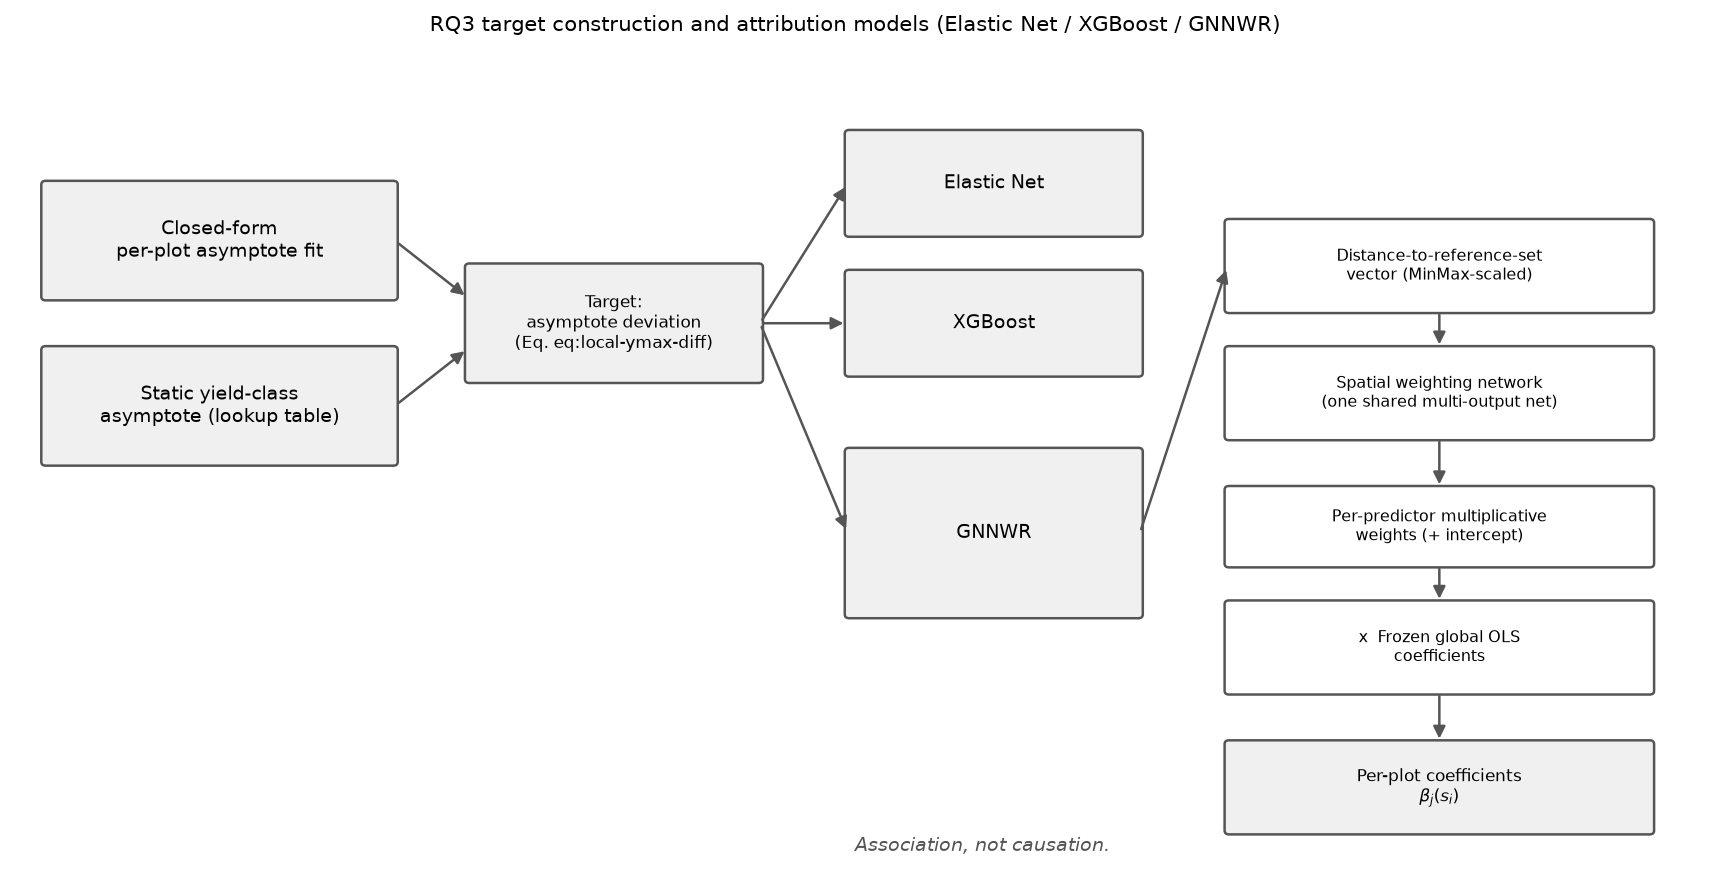

Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/documentation/august_draft/4_Chapter_methodology/figures/rq3_attribution.png


In [10]:
fig, ax = new_schematic_axes(figsize=(11.5, 6), xlim=(0, 11.5), ylim=(0, 6.5))

# --- Target construction (left) ---
draw_box(ax, 0.2, 4.5, 2.4, 0.9, "Closed-form\nper-plot asymptote fit")
draw_box(ax, 0.2, 3.2, 2.4, 0.9, "Static yield-class\nasymptote (lookup table)")
draw_box(ax, 3.1, 3.85, 2.0, 0.9, "Target:\nasymptote deviation\n(Eq. eq:local-ymax-diff)", fontsize=8)

draw_arrow(ax, (2.6, 4.95), (3.1, 4.5))
draw_arrow(ax, (2.6, 3.65), (3.1, 4.1))

# --- Three attribution models ---
draw_box(ax, 5.7, 5.0, 2.0, 0.8, "Elastic Net")
draw_box(ax, 5.7, 3.9, 2.0, 0.8, "XGBoost")
draw_box(ax, 5.7, 2.0, 2.0, 1.3, "GNNWR")

draw_arrow(ax, (5.1, 4.3), (5.7, 5.4))
draw_arrow(ax, (5.1, 4.3), (5.7, 4.3))
draw_arrow(ax, (5.1, 4.3), (5.7, 2.65))

# --- GNNWR internal mechanism (expanded box on the right) ---
draw_box(ax, 8.3, 4.4, 2.9, 0.7, "Distance-to-reference-set\nvector (MinMax-scaled)", facecolor="#FFFFFF", fontsize=7.5)
draw_box(ax, 8.3, 3.4, 2.9, 0.7, "Spatial weighting network\n(one shared multi-output net)", facecolor="#FFFFFF", fontsize=7.5)
draw_box(ax, 8.3, 2.4, 2.9, 0.6, "Per-predictor multiplicative\nweights (+ intercept)", facecolor="#FFFFFF", fontsize=7.5)
draw_box(ax, 8.3, 1.4, 2.9, 0.7, "x  Frozen global OLS\ncoefficients", facecolor="#FFFFFF", fontsize=7.5)
draw_box(ax, 8.3, 0.3, 2.9, 0.7, "Per-plot coefficients\n$\\beta_j(s_i)$", fontsize=8)

draw_arrow(ax, (7.7, 2.65), (8.3, 4.75))
draw_arrow(ax, (9.75, 4.4), (9.75, 4.1))
draw_arrow(ax, (9.75, 3.4), (9.75, 3.0))
draw_arrow(ax, (9.75, 2.4), (9.75, 2.1))
draw_arrow(ax, (9.75, 1.4), (9.75, 1.0))

# Annotation required by the chapter caption.
ax.text(
    5.75, 0.15, "Association, not causation.",
    fontsize=9, style="italic", color=COLOR_NEUTRAL_EDGE,
)

ax.set_title("RQ3 target construction and attribution models (Elastic Net / XGBoost / GNNWR)", fontsize=10)
plt.tight_layout()
out_path = FIGURES_DIR / "rq3_attribution.png"
plt.savefig(out_path)
plt.show()
print("Saved ->", out_path)

## Summary

All five figures are saved to `documentation/august_draft/4_Chapter_methodology/figures/`:

- `age_linearity.png`
- `splits_combined.png`
- `pipeline_overview.png`
- `model_architecture.png`
- `rq3_attribution.png`

Each `FIGURE PLACEHOLDER` box in the `.tex` source can be replaced with
`\includegraphics[width=0.9\textwidth]{4_Chapter_methodology/figures/<name>.png}` pointing at these files.
The three schematic diagrams (pipeline overview, model architecture, RQ3 mechanism) are a reasonable
first pass built directly from the chapter's own caption/spec text -- worth a visual check against the
actual box layout and wording before submission, since a hand-drawn or vector version (e.g. in a
proper diagramming tool) may render more cleanly for print than matplotlib patches at these small
font sizes.